<a href="https://www.kaggle.com/code/felpontes98/suummit-stardataset?scriptVersionId=352249029" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# SUMMIT - Star Dataset to Predict Star Types (Engenharia de Software)

## Felipe da Silva Pontes (RGM: 11241103094)

## Larissa do Espirito Santo (RGM: 11241103184)

# 1. Seleção e justificativa do Dataset

Para o desenvolvimento deste projeto, foi utilizado o Star dataset to predict star types. A escolha desse conjunto de dados foi feita por ele apresentar características de diferentes estrelas e uma variável que identifica seus respectivos tipos, permitindo aplicar técnicas de classificação e predição utilizando o algoritmo SVM.

# 2. Importação das bibliotecas

Nesta etapa, são importadas as bibliotecas necessárias para realizar a leitura e o tratamento dos dados, a preparação das informações para o modelo, o treinamento do algoritmo SVM e a avaliação e visualização dos resultados obtidos.

In [1]:
# Importamos a biblioteca pandas para carregar e manipular os dados em formato de tabela
import pandas as pd

# Importamos o NumPy para realizar operações numéricas de forma eficiente
import numpy as np

# Importamos o Matplotlib para criar e exibir gráficos
import matplotlib.pyplot as plt

# Importamos o Seaborn para facilitar a criação de gráficos estatísticos
import seaborn as sns

# Importamos a função utilizada para separar os dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split

# Importamos o GridSearchCV para testar diferentes combinações de parâmetros do modelo
from sklearn.model_selection import GridSearchCV

# Importamos o StandardScaler para padronizar a escala das variáveis numéricas
from sklearn.preprocessing import StandardScaler

# Importamos o SVC, que é o classificador SVM utilizado para realizar a classificação
from sklearn.svm import SVC

# Importamos métricas para avaliar o desempenho do modelo, como acurácia,
# relatório de classificação e matriz de confusão
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 3. Carregamento e exploração inicial dos dados
Como primeira etapa do tratamento dos dados, realizamos a leitura do dataset e verificamos suas primeiras linhas. Essa análise inicial permite compreender como as informações estão organizadas e identificar as principais características disponíveis para o desenvolvimento do modelo.

In [2]:
# Criamos uma variável para armazenar o caminho do dataset que será utilizado
arq_caminho = "/kaggle/input/datasets/deepu1109/star-dataset/6 class csv.csv"

# Utilizamos o pandas para ler o arquivo CSV e armazenar os dados em um DataFrame
df = pd.read_csv(arq_caminho)

# Exibimos as primeiras linhas do dataset para verificar como os dados estão organizados
print(df.head())

   Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)  \
0             3068          0.002400        0.1700                   16.12   
1             3042          0.000500        0.1542                   16.60   
2             2600          0.000300        0.1020                   18.70   
3             2800          0.000200        0.1600                   16.65   
4             1939          0.000138        0.1030                   20.06   

   Star type Star color Spectral Class  
0          0        Red              M  
1          0        Red              M  
2          0        Red              M  
3          0        Red              M  
4          0        Red              M  


# 4. Estrutura e tipos de dados do Dataset
Nesta etapa, verificamos a estrutura do DataFrame para identificar a quantidade de registros, o número de colunas, os tipos de dados presentes e a existência de possíveis valores ausentes.

In [3]:
# Exibimos informações do DataFrame, incluindo quantidade de registros,
# quantidade de colunas, tipos de dados e possíveis valores ausentes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Temperature (K)         240 non-null    int64  
 1   Luminosity(L/Lo)        240 non-null    float64
 2   Radius(R/Ro)            240 non-null    float64
 3   Absolute magnitude(Mv)  240 non-null    float64
 4   Star type               240 non-null    int64  
 5   Star color              240 non-null    object 
 6   Spectral Class          240 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 13.3+ KB


# 5. Análise estatística das variáveis
Em seguida, realizamos uma análise estatística inicial das variáveis numéricas. São apresentados valores como quantidade de registros, média, desvio padrão, valores mínimo e máximo e quartis, permitindo observar a distribuição e a escala dos dados.

In [4]:
# Exibimos estatísticas descritivas das variáveis numéricas do dataset,
# como quantidade de registros, média, desvio padrão, mínimo e máximo
df.describe()

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type
count,240.000000,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396,2.500000
std,9552.425037,179432.244940,517.155763,10.532512,1.711394
min,1939.000000,0.000080,0.008400,-11.920000,0.000000
25%,3344.250000,0.000865,0.102750,-6.232500,1.000000
50%,5776.000000,0.070500,0.762500,8.313000,2.500000
75%,15055.500000,198050.000000,42.750000,13.697500,4.000000
max,40000.000000,849420.000000,1948.500000,20.060000,5.000000


# 6. Verificação de valores nulos
Antes de utilizar os dados no modelo, verificamos a existência de valores nulos em cada coluna. Essa etapa é importante porque dados ausentes podem exigir tratamento antes do treinamento do algoritmo.

In [5]:
# Contamos a quantidade de valores nulos existentes em cada coluna do dataset
qtd_nulos = df.isnull().sum()

# Exibimos o resultado para verificar se existem dados ausentes que precisam ser tratados
print(qtd_nulos)

Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64


# 7. Preparação e transformação dos dados
Nesta etapa, preparamos os dados para que possam ser utilizados pelo algoritmo SVM. As informações textuais são padronizadas e posteriormente transformadas em valores numéricos por meio do One-Hot Encoding. Também são definidas as variáveis de entrada (X) e a variável alvo (y) utilizada na classificação.

In [6]:
# Removemos espaços extras e padronizamos a escrita da coluna 'Star color'
df['Star color'] = df['Star color'].str.strip().str.title()

# Removemos espaços extras da coluna 'Spectral Class'
df['Spectral Class'] = df['Spectral Class'].str.strip()

# Utilizamos One-Hot Encoding para transformar as colunas de texto em colunas numéricas.
# Cada categoria passa a ser representada por valores 0 ou 1.
df_encoded = pd.get_dummies(df, columns=['Star color', 'Spectral Class'], drop_first=True)

# Separamos as Features (X), que são as características utilizadas pelo modelo
# para realizar a previsão, como temperatura, raio e luminosidade.
# A coluna 'Star type' não faz parte das Features porque será a variável que queremos prever.
X = df_encoded.drop('Star type', axis=1)

# Separamos a variável alvo (y), que representa o tipo de estrela que o modelo deverá prever.
y = df_encoded['Star type']

# 8. Separação dos dados e padronização das variáveis
Nesta etapa, dividimos o dataset em conjuntos de treinamento e teste. Os dados de treinamento são utilizados para que o modelo aprenda os padrões existentes, enquanto os dados de teste são reservados para avaliar seu desempenho. Em seguida, aplicamos a padronização das variáveis para colocá-las em uma escala comparável.

In [7]:
# Dividimos os dados em 80% para treinamento e 20% para teste.
# O modelo utiliza os dados de treino para aprender e os dados de teste para ser avaliado.
# stratify=y mantém uma proporção semelhante das classes de estrelas nos dois conjuntos.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# O SVM é sensível à escala das variáveis.
# Como as características possuem valores muito diferentes entre si,
# utilizamos o StandardScaler para colocá-las em uma escala comparável.
scaler = StandardScaler()

# Calculamos os parâmetros de padronização utilizando os dados de treinamento
# e aplicamos essa transformação ao conjunto de treino.
X_train_scaled = scaler.fit_transform(X_train)

# Aplicamos aos dados de teste a mesma transformação calculada a partir dos dados de treino.
X_test_scaled = scaler.transform(X_test)

# 9. Definição e busca dos hiperparâmetros do SVM
Nesta etapa, definimos diferentes combinações de hiperparâmetros do modelo SVM e utilizamos o GridSearchCV para avaliá-las automaticamente. A busca utiliza validação cruzada para identificar a combinação que apresenta a melhor acurácia média nos dados de treinamento.

In [8]:
# Definimos os hiperparâmetros que serão testados pelo GridSearchCV:
# - C controla o quanto o modelo penaliza classificações incorretas.
# - gamma controla a influência de cada ponto quando utilizamos o kernel RBF.
# - kernel define o tipo de função utilizada pelo SVM para separar as classes.
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['linear', 'rbf']
}

# Criamos o classificador SVM e definimos um random_state para manter os resultados reproduzíveis
svm_model = SVC(random_state=42)

# O GridSearchCV testa as combinações definidas no param_grid.
# A validação cruzada divide os dados de treino em 5 partes para avaliar cada configuração.
# Como utilizamos scoring='accuracy', a configuração com maior acurácia média é selecionada.
# n_jobs=-1 permite utilizar todos os núcleos disponíveis do processador.
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Informamos que a busca pelas melhores combinações de parâmetros será iniciada
print("Iniciando a busca pelos melhores hiperparâmetros...")

# Executamos o treinamento e a busca pelas melhores combinações de hiperparâmetros
grid_search.fit(X_train_scaled, y_train)

# Exibimos os melhores parâmetros encontrados durante a busca
print("MELHORES HIPERPARÂMETROS ENCONTRADOS")
print(grid_search.best_params_)

# Exibimos a acurácia média obtida durante a validação cruzada
print(f"Acurácia média na validação cruzada: {grid_search.best_score_:.4f}")

Iniciando a busca pelos melhores hiperparâmetros...
MELHORES HIPERPARÂMETROS ENCONTRADOS
{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Acurácia média na validação cruzada: 0.9740


# 10. Avaliação do modelo
Após a definição dos melhores hiperparâmetros, utilizamos o modelo selecionado para realizar previsões no conjunto de teste. Em seguida, avaliamos seu desempenho por meio da acurácia e de outras métricas apresentadas no relatório de classificação.

In [9]:
# Selecionamos o melhor modelo encontrado pelo GridSearchCV
melhor_modelo = grid_search.best_estimator_

# Utilizamos o conjunto de teste, que não foi usado no treinamento,
# para realizar previsões em dados que o modelo ainda não tinha visto.
y_pred = melhor_modelo.predict(X_test_scaled)

# Calculamos e exibimos a acurácia final obtida no conjunto de teste
print(f"\nAcurácia final no conjunto de teste: {accuracy_score(y_test, y_pred):.4f}\n")

# Exibimos métricas detalhadas de classificação para cada tipo de estrela
print("Relatório de Classificação Detalhado:")
print(classification_report(y_test, y_pred))


Acurácia final no conjunto de teste: 0.9792

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         8
           3       0.89      1.00      0.94         8
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00         8

    accuracy                           0.98        48
   macro avg       0.98      0.98      0.98        48
weighted avg       0.98      0.98      0.98        48



# 11. Matriz de confusão
Nesta etapa, utilizamos uma matriz de confusão para representar visualmente o desempenho do modelo. Ela permite identificar a quantidade de classificações corretas e incorretas para cada tipo de estrela, facilitando a análise dos resultados obtidos.

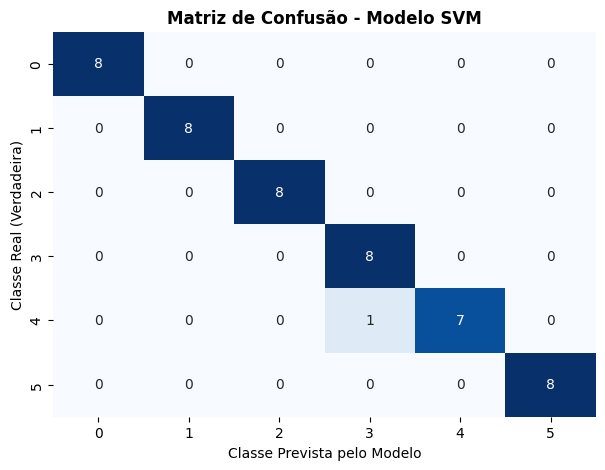

In [10]:
# Criamos uma área para exibir a matriz de confusão
plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred),

    # Mostra a quantidade de previsões dentro de cada célula
    annot=True,

    # Exibe os valores como números inteiros
    fmt='d',

    # Utilizamos tons de azul para facilitar a visualização dos valores
    cmap='Blues',

    # Removemos a barra de cores lateral, pois os valores já aparecem nas células
    cbar=False
)

# Definimos o título do gráfico
plt.title('Matriz de Confusão - Modelo SVM', fontsize=12, fontweight='bold')

# Identificamos no eixo X as classes previstas pelo modelo
plt.xlabel('Classe Prevista pelo Modelo', fontsize=10)

# Identificamos no eixo Y as classes reais presentes nos dados
plt.ylabel('Classe Real (Verdadeira)', fontsize=10)

# Exibimos o gráfico
plt.show()

# 12. Relação entre temperatura e luminosidade
Por fim, utilizamos um gráfico de dispersão para observar visualmente a relação entre a temperatura e a luminosidade das estrelas. As diferentes cores representam os tipos de estrela, permitindo visualizar como essas características estão distribuídas entre as classes do dataset.

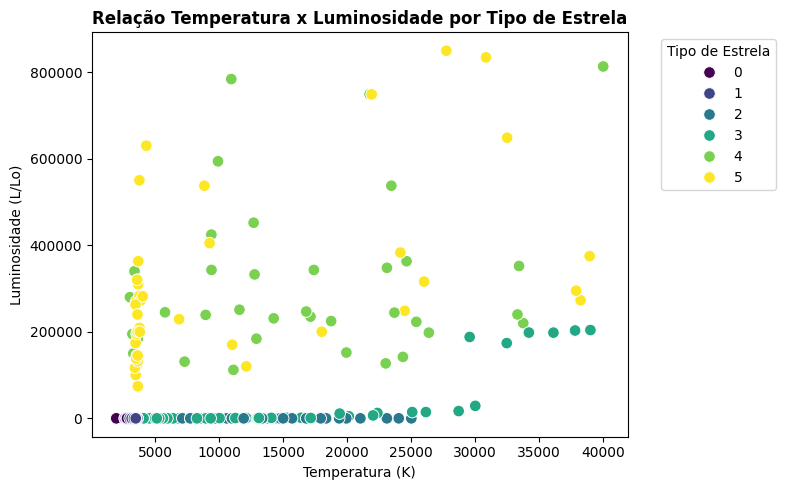

In [11]:
# Criamos uma área para exibir o gráfico de dispersão
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,

    # Utilizamos a temperatura como variável do eixo X
    x='Temperature (K)',

    # Utilizamos a luminosidade como variável do eixo Y
    y='Luminosity(L/Lo)',

    # Utilizamos o tipo de estrela para diferenciar as categorias pelas cores
    hue='Star type',

    # Utilizamos uma paleta de cores para facilitar a diferenciação das classes
    palette='viridis',

    # Definimos o tamanho dos pontos no gráfico
    s=70
)

# Definimos o título do gráfico
plt.title(
    'Relação Temperatura x Luminosidade por Tipo de Estrela',
    fontsize=12,
    fontweight='bold'
)

# Identificamos o eixo X como temperatura em Kelvin
plt.xlabel('Temperatura (K)', fontsize=10)

# Identificamos o eixo Y como luminosidade em relação ao Sol
plt.ylabel('Luminosidade (L/Lo)', fontsize=10)

# Exibimos uma legenda para identificar cada tipo de estrela
plt.legend(
    title='Tipo de Estrela',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Ajustamos automaticamente o espaçamento do gráfico
plt.tight_layout()

# Exibimos o gráfico
plt.show()